# Professional Quant Backtesting

In [1]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# LOAD FEATURES
df_features = pd.read_parquet('processed_features.parquet')

print(f"Data successfully loaded! Shape: {df_features.shape}")
print(df_features.head())

Data successfully loaded! Shape: (1509, 61)
Price                        Close       High        Low       Open  \
Date                                                                  
1970-01-01 00:25:14.851  40.304176  40.313537  39.602258  39.812835   
1970-01-01 00:25:14.937  40.297161  40.839980  40.233991  40.367354   
1970-01-01 00:25:15.024  40.484325  40.587274  40.262052  40.369677   
1970-01-01 00:25:15.110  40.945259  41.031828  40.489013  40.580262   
1970-01-01 00:25:15.369  40.793182  41.087987  40.694911  40.793182   

Price                       Volume  return_1d  return_3d  return_5d  \
Date                                                                  
1970-01-01 00:25:14.851  102223600        NaN        NaN        NaN   
1970-01-01 00:25:14.937  118071600  -0.000174        NaN        NaN   
1970-01-01 00:25:15.024   89738400   0.004645        NaN        NaN   
1970-01-01 00:25:15.110   94640000   0.011385   0.015906        NaN   
1970-01-01 00:25:15.369   822712

In [2]:
# TRAIN / HOLDOUT SPLIT (time-aware)
# Drop Target if already in df_features to avoid duplication
feature_cols = [col for col in df_features.columns if col != 'Target']

# Recreate Target from return_1d (next-day direction)
df_features['Target'] = (df_features['return_1d'].shift(-1) > 0).astype(int)
df_features = df_features.dropna()

X = df_features[feature_cols]
y = df_features['Target']

split_idx = int(len(X) * 0.80)

X_train, X_holdout = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_holdout = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train  : {X_train.shape[0]} rows  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Holdout: {X_holdout.shape[0]} rows  ({X_holdout.index[0].date()} → {X_holdout.index[-1].date()})")


Train  : 1035 rows  (1970-01-01 → 1970-01-01)
Holdout: 259 rows  (1970-01-01 → 1970-01-01)


In [3]:
# TRAIN XGBOOST MODEL
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_holdout, y_holdout)],
    verbose=50
)

print("Model training complete.")

[0]	validation_0-logloss:0.68815
[50]	validation_0-logloss:0.74192
[100]	validation_0-logloss:0.77309
[150]	validation_0-logloss:0.81690
[200]	validation_0-logloss:0.83224
[250]	validation_0-logloss:0.85373
[299]	validation_0-logloss:0.86866
Model training complete.


In [5]:
# PREDICT PROBABILITIES ON HOLDOUT
tuned_proba = model.predict_proba(X_holdout)[:, 1]  # P(up-day)

print(f"Predicted proba — mean: {tuned_proba.mean():.3f}  "
      f"min: {tuned_proba.min():.3f}  "
      f"max: {tuned_proba.max():.3f}")

Predicted proba — mean: 0.343  min: 0.043  max: 0.920


In [6]:
# BACKTEST ENGINE
def full_backtest(signal_proba, actual_returns, threshold=0.5,
                  transaction_cost=0.001, name="Strategy"):
    """
    Full backtest engine with transaction costs and risk metrics.

    signal_proba:     model's predicted probability of an up day
    actual_returns:   the actual daily returns that occurred
    threshold:        probability above which we go long
    transaction_cost: 0.1% per trade (0.001) — realistic for retail
    """
    signals = (signal_proba > threshold).astype(int)
    prev_sig = signals.shift(1).fillna(0)
    trades = (signals != prev_sig).astype(int)

    strategy_returns = signals * actual_returns - trades * transaction_cost

    total_days = len(strategy_returns)
    trading_days_per_year = 252
    years = total_days / trading_days_per_year

    cum_return_strat = (1 + strategy_returns).prod() - 1
    ann_return = (1 + cum_return_strat) ** (1 / years) - 1
    ann_vol = strategy_returns.std() * np.sqrt(trading_days_per_year)

    rf_daily = 0.05 / trading_days_per_year
    excess = strategy_returns - rf_daily
    sharpe = (excess.mean() / excess.std()) * np.sqrt(trading_days_per_year)

    downside_returns = strategy_returns[strategy_returns < rf_daily]
    downside_vol = downside_returns.std() * np.sqrt(trading_days_per_year)
    sortino = (ann_return - 0.05) / downside_vol if downside_vol > 0 else np.nan

    cum_equity = (1 + strategy_returns).cumprod()
    rolling_max = cum_equity.cummax()
    drawdown = (cum_equity - rolling_max) / rolling_max
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    wins = strategy_returns[strategy_returns > 0]
    losses = strategy_returns[strategy_returns < 0]
    win_rate = len(wins) / len(strategy_returns[strategy_returns != 0])
    profit_factor = wins.sum() / abs(losses.sum()) if len(losses) > 0 else np.nan

    n_trades = trades.sum()
    days_in_mkt = signals.sum()

    print(f"\n{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    print(f"  Period:              {total_days} days ({years:.1f} years)")
    print(f"  Trades:              {n_trades}")
    print(f"  Days in market:      {days_in_mkt} ({days_in_mkt / total_days:.1%})")
    print(f"  ─────────────────────────────────────────")
    print(f"  Cumulative return:   {cum_return_strat:.2%}")
    print(f"  Annualized return:   {ann_return:.2%}")
    print(f"  Annualized vol:      {ann_vol:.2%}")
    print(f"  ─────────────────────────────────────────")
    print(f"  Sharpe Ratio:        {sharpe:.3f}")
    print(f"  Sortino Ratio:       {sortino:.3f}")
    print(f"  Calmar Ratio:        {calmar:.3f}")
    print(f"  Max Drawdown:        {max_dd:.2%}")
    print(f"  ─────────────────────────────────────────")
    print(f"  Win rate:            {win_rate:.2%}")
    print(f"  Profit factor:       {profit_factor:.3f}")
    print(f"{'=' * 50}")

    return {
        'cum_returns': cum_equity,
        'drawdown': drawdown,
        'strategy_rets': strategy_returns,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'ann_return': ann_return
    }


In [7]:
# RUN BACKTEST
actual_rets_holdout = df_features.loc[X_holdout.index, 'return_1d']

backtest_result = full_backtest(
    signal_proba=pd.Series(tuned_proba, index=X_holdout.index),
    actual_returns=actual_rets_holdout,
    threshold=0.5,
    transaction_cost=0.001,
    name="XGBoost ML Strategy"
)

bh_result = full_backtest(
    signal_proba=pd.Series(np.ones(len(X_holdout)), index=X_holdout.index),
    actual_returns=actual_rets_holdout,
    threshold=0.5,
    transaction_cost=0,
    name="Buy and Hold (AAPL)"
)



  XGBoost ML Strategy
  Period:              259 days (1.0 years)
  Trades:              50
  Days in market:      55 (21.2%)
  ─────────────────────────────────────────
  Cumulative return:   -1.91%
  Annualized return:   -1.85%
  Annualized vol:      10.86%
  ─────────────────────────────────────────
  Sharpe Ratio:        -0.578
  Sortino Ratio:       -0.863
  Calmar Ratio:        -0.238
  Max Drawdown:        -7.79%
  ─────────────────────────────────────────
  Win rate:            35.00%
  Profit factor:       0.961

  Buy and Hold (AAPL)
  Period:              259 days (1.0 years)
  Trades:              1
  Days in market:      259 (100.0%)
  ─────────────────────────────────────────
  Cumulative return:   41.66%
  Annualized return:   40.33%
  Annualized vol:      20.83%
  ─────────────────────────────────────────
  Sharpe Ratio:        1.491
  Sortino Ratio:       2.652
  Calmar Ratio:        2.681
  Max Drawdown:        -15.04%
  ─────────────────────────────────────────
  Wi

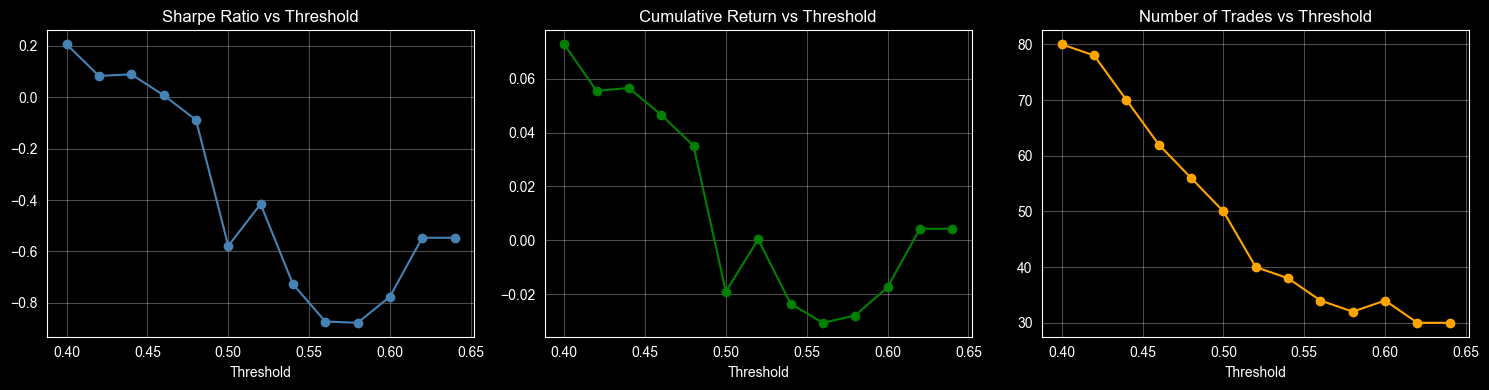


Optimal threshold: 0.40
           sharpe  cum_return  n_trades  pct_long
threshold                                        
0.40        0.206       0.073        80     0.340
0.42        0.083       0.056        78     0.317
0.44        0.089       0.057        70     0.270
0.46        0.008       0.047        62     0.247
0.48       -0.088       0.035        56     0.232
0.50       -0.578      -0.019        50     0.212
0.52       -0.415       0.000        40     0.189
0.54       -0.727      -0.024        38     0.166
0.56       -0.872      -0.031        34     0.143
0.58       -0.877      -0.028        32     0.127
0.60       -0.776      -0.017        34     0.116
0.62       -0.547       0.004        30     0.104
0.64       -0.547       0.004        30     0.104


In [8]:
# THRESHOLD OPTIMISATION
thresholds = np.arange(0.4, 0.65, 0.02)
threshold_results = []

for t in thresholds:
    signals = (pd.Series(tuned_proba) > t).astype(int)
    strat_returns = signals.values * actual_rets_holdout.values - \
                    (signals.values != np.roll(signals.values, 1)).astype(int) * 0.001
    strat_returns = pd.Series(strat_returns)
    rf = 0.05 / 252
    sharpe = ((strat_returns - rf).mean() / strat_returns.std()) * np.sqrt(252)
    cum_ret = (1 + strat_returns).prod() - 1
    threshold_results.append({
        'threshold': t,
        'sharpe': sharpe,
        'cum_return': cum_ret,
        'n_trades': (signals != signals.shift(1)).sum(),
        'pct_long': signals.mean()
    })

thresh_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(thresh_df['threshold'], thresh_df['sharpe'], 'o-', color='steelblue')
axes[0].set_title('Sharpe Ratio vs Threshold');
axes[0].set_xlabel('Threshold');
axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['threshold'], thresh_df['cum_return'], 'o-', color='green')
axes[1].set_title('Cumulative Return vs Threshold');
axes[1].set_xlabel('Threshold');
axes[1].grid(True, alpha=0.3)
axes[2].plot(thresh_df['threshold'], thresh_df['n_trades'], 'o-', color='orange')
axes[2].set_title('Number of Trades vs Threshold');
axes[2].set_xlabel('Threshold');
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_thresh = thresh_df.loc[thresh_df['sharpe'].idxmax(), 'threshold']
print(f"\nOptimal threshold: {best_thresh:.2f}")
print(thresh_df.set_index('threshold').round(3))


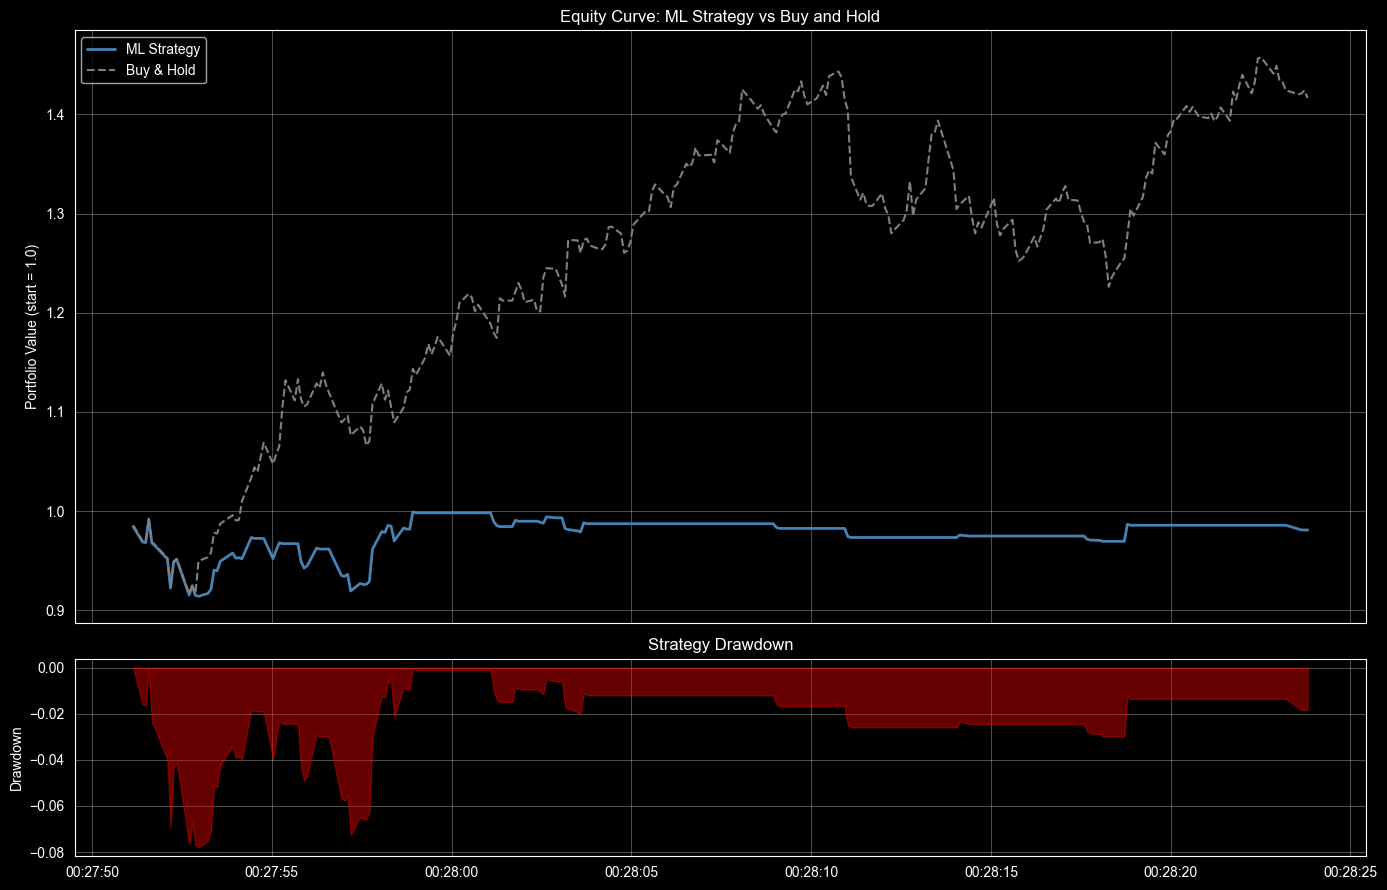

In [9]:
# EQUITY CURVE + DRAWDOWN PLOT
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(backtest_result['cum_returns'].index,
         backtest_result['cum_returns'].values, label='ML Strategy', color='steelblue', lw=2)
ax1.plot(bh_result['cum_returns'].index,
         bh_result['cum_returns'].values, label='Buy & Hold', color='gray', lw=1.5, ls='--')
ax1.set_title('Equity Curve: ML Strategy vs Buy and Hold')
ax1.set_ylabel('Portfolio Value (start = 1.0)')
ax1.legend();
ax1.grid(True, alpha=0.3)

ax2.fill_between(backtest_result['drawdown'].index,
                 backtest_result['drawdown'].values, 0, color='red', alpha=0.4)
ax2.set_title('Strategy Drawdown')
ax2.set_ylabel('Drawdown')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()